# Initial Protein Dataset Analysis

Exploratory analysis of the processed protein dataset built from per-protein
metadata JSONs.  Distribution plots for key biological and structural
properties, organism breakdown, and dataset-level statistics.

In [1]:
# ── Display setup ─────────────────────────────────────────────────────────────
import os
os.environ.setdefault("DISPLAY", ":0")
os.environ.setdefault("WAYLAND_DISPLAY", "wayland-0")
os.environ.setdefault("XDG_RUNTIME_DIR", "/mnt/wslg/runtime-dir")

'/run/user/1000/'

In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

PROJECT_ROOT = Path("../").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import get_data_root

data_root = Path(get_data_root())
print("data_root:", data_root)

data_root: /home/skyle/external_protein_data


---
## Build Dataset

Load all per-protein metadata JSONs into a single DataFrame.
`plddt_per_residue` is excluded (it is a per-residue list, not a scalar).

In [3]:
# ── Load metadata into DataFrame ──────────────────────────────────────────────
EXCLUDE_FIELDS = {"plddt_per_residue", "pipeline_steps"}

rows = []
for protein_dir in sorted(data_root.iterdir()):
    meta_file = protein_dir / f"{protein_dir.name}_metadata.json"
    if not meta_file.exists():
        continue
    meta = json.loads(meta_file.read_text())
    rows.append({k: v for k, v in meta.items() if k not in EXCLUDE_FIELDS})

df = pd.DataFrame(rows)

# Numeric coercion for key columns
for col in ["sequence_length", "plddt_mean", "plddt_median",
            "n_heavy_atoms", "net_charge", "ses_area_pqr",
            "n_vertices_pqr", "pearson_r_pqr", "rmse_pqr"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Proteins loaded : {len(df):,}")
print(f"Columns         : {list(df.columns)}")
df.head(3)

Proteins loaded : 200
Columns         : ['protein_id', 'uniprot_id', 'fragment', 'protein_name', 'organism', 'sequence_length', 'af_model_version', 'plddt_mean', 'plddt_median', 'n_heavy_atoms', 'net_charge', 'time_pdb2pqr_sec', 'time_apbs_sec', 'n_vertices_pqr', 'ses_area_pqr', 'time_mesh_pqr_sec', 'time_esp_sampling_sec', 'pearson_r_pqr', 'rmse_pqr', 'time_total_sec', 'pipeline_complete']


,protein_id,uniprot_id,fragment,protein_name,organism,sequence_length,af_model_version,plddt_mean,plddt_median,n_heavy_atoms,...,time_pdb2pqr_sec,time_apbs_sec,n_vertices_pqr,ses_area_pqr,time_mesh_pqr_sec,time_esp_sampling_sec,pearson_r_pqr,rmse_pqr,time_total_sec,pipeline_complete
0,AF-A0A085GHR3-F1,A0A085GHR3,1,Type III effector protein HopBF1,Ewingella americana (strain ATCC 33852 / DSM 4...,203,6,88.9238,96.00,1583,...,0.759,8.893,28805,10286.767,0.165,0.399,0.970980,0.672551,12.505,True
1,AF-A0A097ZPE8-F1,A0A097ZPE8,1,Short chain dehydrogenase andI,Emericella variicolor,290,6,95.5439,98.00,2213,...,1.010,5.879,32208,11435.372,0.190,0.388,0.986196,0.722052,8.941,True
2,AF-A0A0D1DWQ2-F1,A0A0D1DWQ2,1,Secreted chorismate mutase,Mycosarcoma maydis,290,6,91.2248,97.09,2246,...,1.003,18.022,40697,14584.411,0.217,0.491,0.973058,0.685079,23.716,True


---
## Dataset Overview

In [4]:
# ── Dataset summary ───────────────────────────────────────────────────────────
n_total    = len(df)
n_complete = int(df["pipeline_complete"].sum()) if "pipeline_complete" in df.columns else "n/a"
n_frags    = df["fragment"].nunique() if "fragment" in df.columns else "n/a"
n_orgs     = df["organism"].nunique() if "organism" in df.columns else "n/a"

print(f"Total proteins          : {n_total:,}")
print(f"Pipeline complete       : {n_complete:,}")
print(f"Unique fragment numbers : {n_frags}")
print(f"Unique organisms        : {n_orgs}")
print()

STAT_COLS = ["sequence_length", "plddt_mean", "n_heavy_atoms",
             "net_charge", "ses_area_pqr"]
present = [c for c in STAT_COLS if c in df.columns]
df[present].describe().round(3)

Total proteins          : 200
Pipeline complete       : 200
Unique fragment numbers : 1
Unique organisms        : 92



,sequence_length,plddt_mean,n_heavy_atoms,net_charge,ses_area_pqr
count,200.000,200.000,200.000,200.00,200.000
mean,452.620,80.776,3553.740,-2.13,25360.939
std,247.863,13.852,1941.874,12.92,16273.276
min,40.000,36.080,305.000,-42.00,2713.650
25%,214.500,73.569,1653.250,-9.00,12788.464
50%,403.500,84.721,3211.500,-2.00,21587.552
75%,671.500,91.833,5210.250,4.00,37843.971
max,990.000,98.560,7719.000,37.00,79616.586


---
## Distribution Plots

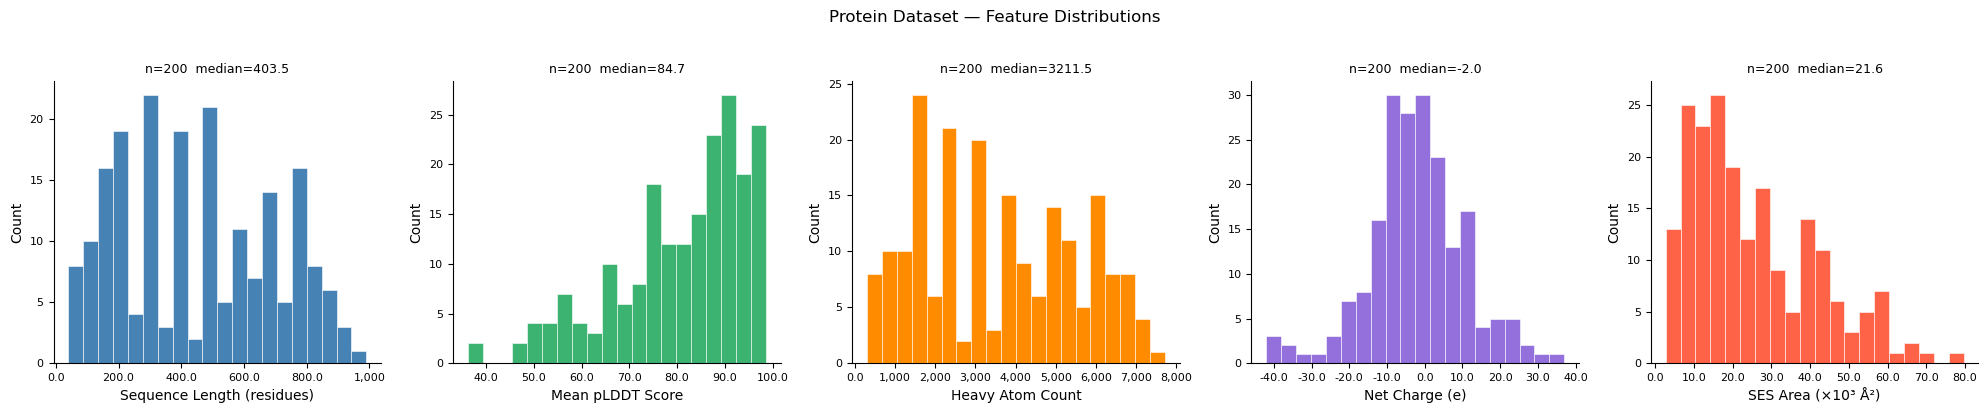

In [7]:
# ── Distribution histograms ────────────────────────────────────────────────────
PLOT_COLS = [
    ("sequence_length", "Sequence Length (residues)",  "steelblue"),
    ("plddt_mean",      "Mean pLDDT Score",            "mediumseagreen"),
    ("n_heavy_atoms",   "Heavy Atom Count",            "darkorange"),
    ("net_charge",      "Net Charge (e)",              "mediumpurple"),
    ("ses_area_pqr",    "SES Area (Å²)",               "tomato"),
]

# Filter to columns actually present in the dataset
PLOT_COLS = [(col, lbl, clr) for col, lbl, clr in PLOT_COLS if col in df.columns]

fig, axes = plt.subplots(1, len(PLOT_COLS), figsize=(4 * len(PLOT_COLS), 4))
if len(PLOT_COLS) == 1:
    axes = [axes]

for ax, (col, label, color) in zip(axes, PLOT_COLS):
    data = df[col].dropna()
    
    if col == "ses_area_pqr":
        data = data / 1_000
        label = "SES Area (×10³ Å²)"
        
    ax.hist(data, bins=20, color=color, edgecolor="white", linewidth=0.4)
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(f"n={len(data):,}  median={data.median():.1f}", fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x:,.0f}" if abs(x) >= 1000 else f"{x:.1f}"
    ))
    ax.tick_params(labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Protein Dataset — Feature Distributions", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

---
## Organism Breakdown

In [6]:
# ── Organism counts ───────────────────────────────────────────────────────────
if "organism" not in df.columns:
    print("No 'organism' field in dataset.")
else:
    org_counts = (
        df["organism"]
        .fillna("Unknown")
        .value_counts()
        .reset_index()
        .rename(columns={"organism": "organism", "count": "n_proteins"})
    )

    print(f"{len(org_counts)} unique organisms across {len(df)} proteins")
    print()
    print(org_counts.to_string(index=False))

92 unique organisms across 200 proteins

                                                                                                                                       organism  n_proteins
                                                                                                                                   Homo sapiens          85
                                                                                                                         Caenorhabditis elegans          10
                                                                                                                           Arabidopsis thaliana           6
                                                                                                       Burkholderia cenocepacia (strain HI2424)           4
                                                                                                                                   Mus musculus           3
                       